In [1]:
import numpy as np

def read_prof_pressure(filepath):
    pressures = []
    reading = False

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("(pressure"):
                reading = True
                continue

            if reading:
                if line.startswith(")"):
                    break
                pressures.append(float(line))

    return np.array(pressures)

In [ ]:
def compute_risk(pressure_array, rupture_pressure):
    p_max = np.max(np.abs(pressure_array))
    risk = min(1.0, 1.5 * p_max / rupture_pressure)
    return risk


In [3]:
import pandas as pd
import glob
import re

rupture_pressure = 355

rows = []

for filepath in glob.glob("cfd/*.prof"):
    # extrai ângulo e velocidade do nome do arquivo
    match = re.search(r"ang_(\d+)_vel_(\d+)", filepath)
    if not match:
        continue

    angle = float(match.group(1))
    velocity = float(match.group(2))

    pressure = read_prof_pressure(filepath)
    risk = compute_risk(pressure, rupture_pressure)

    rows.append({
        "angle": angle,
        "velocity": velocity,
        "risk": risk
    })

df_risk = pd.DataFrame(rows)
df_risk.to_csv("risk_cfd.csv", index=False)


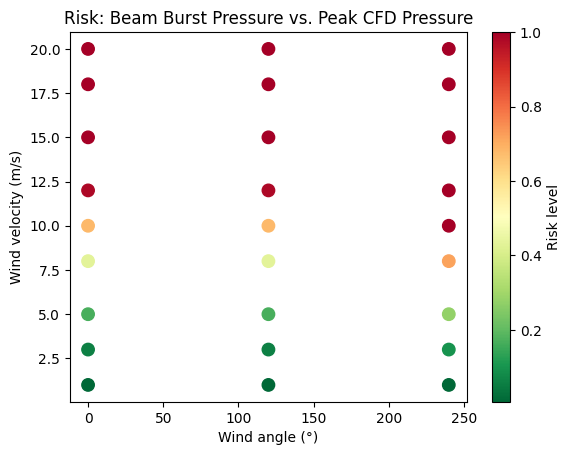

In [5]:
import matplotlib.pyplot as plt

plt.scatter(
    df_risk["angle"],
    df_risk["velocity"],
    c=df_risk["risk"],
    cmap="RdYlGn_r",
    s=80
)
plt.colorbar(label="Risk level")
plt.xlabel("Wind angle (°)")
plt.ylabel("Wind velocity (m/s)")
plt.title("Risk: Beam Burst Pressure vs. Peak CFD Pressure")
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

X = df_risk[["angle", "velocity"]]
y = df_risk["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.9919107474881708
RMSE: 0.03921700240309368


In [7]:
df_result = pd.read_csv("result_wind_center.csv")

df_pred = df_result[["angle", "velocity"]].copy()
df_pred["risk_pred"] = model.predict(df_pred)
df_pred["risk_pred"] = df_pred["risk_pred"].clip(0, 1)


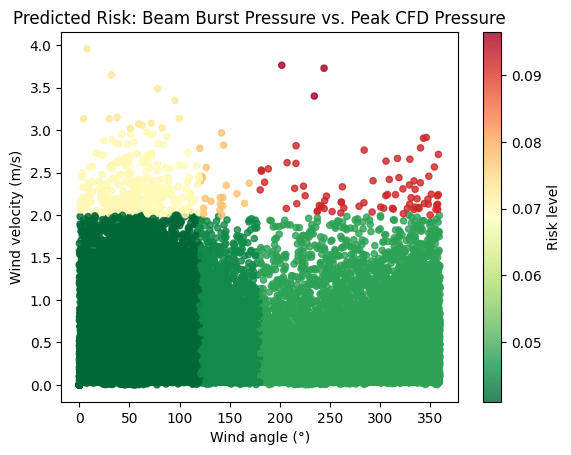

In [9]:
plt.scatter(
    df_pred["angle"],
    df_pred["velocity"],
    c=df_pred["risk_pred"],
    cmap="RdYlGn_r",
    s=20,
    alpha=0.8
)
plt.colorbar(label="Risk level")
plt.xlabel("Wind angle (°)")
plt.ylabel("Wind velocity (m/s)")
plt.title("Predicted Risk: Beam Burst Pressure vs. Peak CFD Pressure")
plt.show()


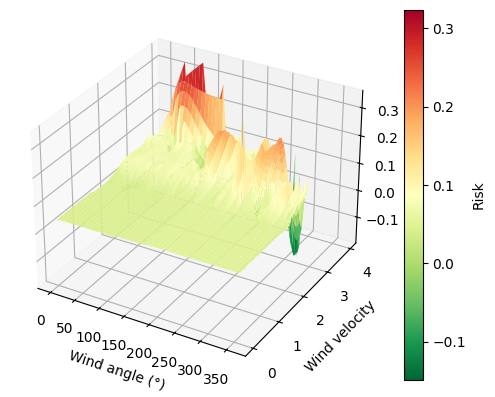

In [ ]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = df_pred["angle"].values
y = df_pred["velocity"].values
z = df_pred["risk_pred"].values

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# Perform cubic interpolation, then fill any NaNs with nearest-neighbor results
ZI = griddata((x, y), z, (XI, YI), method="cubic")
ZI_nearest = griddata((x, y), z, (XI, YI), method="nearest")
ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)

# Ensure finite values and clamp to [0,1] so risk stays within valid bounds
ZI = np.nan_to_num(ZI, nan=0.0, posinf=1.0, neginf=0.0)
ZI = np.clip(ZI, 0.0, 1.0)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

surf = ax.plot_surface(
    XI, YI, ZI,
    cmap="RdYlGn_r",
    linewidth=0,
    antialiased=False
)

ax.set_xlabel("Wind angle (°)")
ax.set_ylabel("Wind velocity")
ax.set_zlabel("Risk level")

fig.colorbar(surf, label="Risk")

plt.show()
